$ \mathbb{R}^d \to \mathbb{R}$. A 2-hidden-layer MLP with width $w=64$ and $\tanh$ nonlinearity:

$$
g_\theta(x) \;=\; W_3\,\tanh\!\Big(W_2\,\tanh\big(W_1 x + b_1\big) + b_2\Big) + b_3,
$$

with parameters $\theta = \{W_1 \in \mathbb{R}^{w \times d},\,b_1 \in \mathbb{R}^w,\;W_2 \in \mathbb{R}^{w \times w},\,b_2 \in \mathbb{R}^w,\;W_3 \in \mathbb{R}^{1 \times w},\,b_3 \in \mathbb{R}\}$.

In [9]:
import torch, torch.nn as nn
import numpy as np, matplotlib.pyplot as plt
torch.manual_seed(0); np.random.seed(0)

def MLP(d_in, width=64):
    return nn.Sequential(
        nn.Linear(d_in, width), nn.Tanh(),
        nn.Linear(width, width), nn.Tanh(),
        nn.Linear(width, 1),
    )


$$
\begin{aligned}
\text{Baseline:} \quad     & h_\theta(x) \;=\; g_\theta(x), \\[2pt]
\text{Symmetrized :} \quad & h_\theta(x) \;=\; \tfrac{1}{2}\big(g_\theta(x) + g_\theta(-x)\big), \\[2pt]
\text{Even features :} \quad & h_\theta(x) \;=\; g_\theta(x \odot x),
\end{aligned}
$$

where both (A) and (B) satisfy $h_\theta(-x) = h_\theta(x)$ by construction; the baseline does not.

In [10]:

class Baseline(nn.Module):
    name = 'baseline'
    def __init__(self, d): super().__init__(); self.g = MLP(d)
    def forward(self, x): return self.g(x).squeeze(-1)

class Symmetrized(nn.Module):           # h(x) = 1/2 ( g(x) + g(-x) )
    name = 'symmetrized'
    def __init__(self, d): super().__init__(); self.g = MLP(d)
    def forward(self, x): return 0.5 * (self.g(x) + self.g(-x)).squeeze(-1)

class EvenFeatures(nn.Module):          # h(x) = g(x * x)
    name = 'even-features'
    def __init__(self, d): super().__init__(); self.g = MLP(d)
    def forward(self, x): return self.g(x * x).squeeze(-1)



**Training:**

Given data $\{(x_i, y_i)\}_{i=1}^N$, we minimize the mean squared error

$$
L(\theta) \;=\; \frac{1}{N}\sum_{i=1}^{N}\big(h_\theta(x_i) - y_i\big)^2
$$

for $T = 4000$ steps with learning rate $\eta = 3 \times 10^{-3}$.
At step $t$, Adam tracks running gradient moments

$$
m_t = \beta_1 m_{t-1} + (1-\beta_1)\, g_t, \qquad
v_t = \beta_2 v_{t-1} + (1-\beta_2)\, g_t^2, \qquad
g_t \equiv \nabla_\theta L(\theta_{t-1}),
$$

bias-corrects $\hat m_t = m_t/(1-\beta_1^t)$, $\hat v_t = v_t/(1-\beta_2^t)$, and updates

$$
\theta_t = \theta_{t-1} - \eta\,\frac{\hat m_t}{\sqrt{\hat v_t} + \varepsilon},
$$

with PyTorch defaults $\beta_1=0.9$, $\beta_2=0.999$, $\varepsilon=10^{-8}$. train returns $\{L(\theta_t)\}_{t=0}^{T-1}$ for plotting.

In [11]:
def train(model, X, y, steps=4000, lr=3e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    for _ in range(steps):
        loss = ((model(X) - y) ** 2).mean()
        opt.zero_grad(); loss.backward(); opt.step()
        losses.append(loss.item())
    return losses

MODELS = (Baseline, Symmetrized, EvenFeatures)
COLORS = {'baseline':'#d62728','symmetrized':'#2ca02c','even-features':'#1f77b4'}

In [16]:
# proof
torch.manual_seed(42)
x = torch.randn(8, 2)   # random inputs in R^2

print(f"{'model':14s}  {'max |h(x) - h(-x)|':>22s}")
print("-" * 40)
for M in MODELS:
    torch.manual_seed(0)         # same random init for fairness
    m = M(d=2)
    with torch.no_grad():
        diff = (m(x) - m(-x)).abs().max().item()
    flag = "  -- not symmetric" if diff > 1e-6 else ""
    print(f"{m.name:14s}  {diff:22.2e}{flag}")

model               max |h(x) - h(-x)|
----------------------------------------
baseline                      5.71e-01  -- not symmetric
symmetrized                   0.00e+00
even-features                 0.00e+00


##### 1D
##### $f(x)=x^4-3x^2+\cos(2x)$
60 noisy points sampled from $x>0$; test on $[-3,3]$.

baseline        train MSE=0.002195   test MSE=9.372
symmetrized     train MSE=0.002188   test MSE=0.000321
even-features   train MSE=0.002159   test MSE=0.0003655


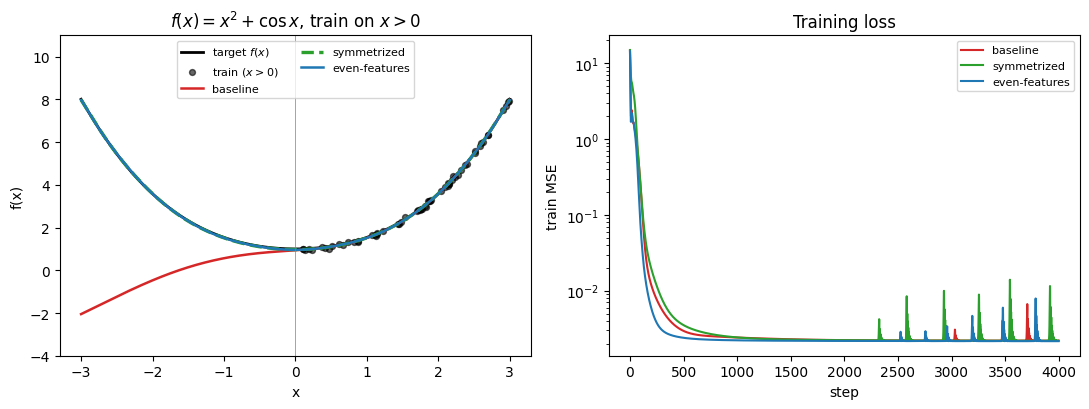

In [17]:
f1 = lambda x: x**2 + torch.cos(x)
Xtr = torch.empty(60,1).uniform_(0.05, 3.0)
ytr = f1(Xtr[:,0]) + 0.05*torch.randn(60)
Xg  = torch.linspace(-3, 3, 400).unsqueeze(-1); yg = f1(Xg[:,0])

STYLES = {'baseline':'-', 'symmetrized':'--', 'even-features':'-'}
LW     = {'baseline':1.8, 'symmetrized':2.4, 'even-features':1.8}

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].plot(Xg, yg, 'k-', lw=2, label='target $f(x)$')
ax[0].scatter(Xtr, ytr, s=18, c='k', alpha=0.6, label='train ($x>0$)')
for M in MODELS:
    torch.manual_seed(1); m = M(d=1)
    losses = train(m, Xtr, ytr)
    with torch.no_grad(): yhat = m(Xg)
    print(f'{m.name:14s}  train MSE={losses[-1]:.4g}   test MSE={((yhat-yg)**2).mean():.4g}')
    ax[0].plot(Xg, yhat, STYLES[m.name], color=COLORS[m.name], lw=LW[m.name], label=m.name)
    ax[1].semilogy(losses, color=COLORS[m.name], label=m.name)

ax[0].axvline(0, color='gray', lw=0.5); ax[0].set_ylim(-4, 11)
ax[0].set_xlabel('x'); ax[0].set_ylabel('f(x)')
ax[0].set_title(r'$f(x)=x^2+\cos x$, train on $x>0$')
ax[0].legend(fontsize=8, loc='upper center', ncol=2)
ax[1].set_xlabel('step'); ax[1].set_ylabel('train MSE')
ax[1].set_title('Training loss'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

#####2D
#####Target $f(x_1,x_2) = x_1^2 + x_2^2 + x_1 x_2 = x^\top A x$,
with $A = \begin{pmatrix}1 & 1/2 \\ 1/2 & 1\end{pmatrix}$.


      n        baseline     symmetrized   even-features
     15          2.4817          0.3591          4.8692
     30          0.2540          0.0256          4.5948
     60          0.0386          0.0065          4.4399
    120          0.0048          0.0023          4.5732
    240          0.0019          0.0018          4.3966


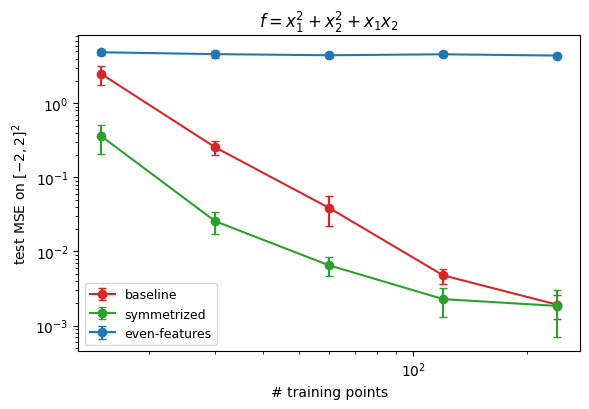

In [18]:
f2 = lambda X: X[:,0]**2 + X[:,1]**2 + X[:,0]*X[:,1]
Xte = torch.empty(2000,2).uniform_(-2,2); yte = f2(Xte)
ns, trials = [15,30,60,120,240], 5
res = {M.name: {n:[] for n in ns} for M in MODELS}

for n in ns:
    for tr in range(trials):
        Xtr = torch.empty(n,2).uniform_(-2,2)
        ytr = f2(Xtr) + 0.05*torch.randn(n)
        for M in MODELS:
            torch.manual_seed(1000*tr+7); m = M(d=2)
            train(m, Xtr, ytr, steps=3000)
            with torch.no_grad():
                res[m.name][n].append(((m(Xte)-yte)**2).mean().item())

print(f"  {'n':>5s} " + ' '.join(f'{k:>15s}' for k in res))
for n in ns:
    print(f'  {n:5d} ' + ' '.join(f'{np.mean(res[k][n]):15.4f}' for k in res))

plt.figure(figsize=(6, 4.2))
for k in res:
    mu = [np.mean(res[k][n]) for n in ns]
    se = [np.std(res[k][n])/np.sqrt(trials) for n in ns]
    plt.errorbar(ns, mu, yerr=se, marker='o', color=COLORS[k], label=k, capsize=3)
plt.xscale('log'); plt.yscale('log')
plt.xlabel('# training points'); plt.ylabel(r'test MSE on $[-2,2]^2$')
plt.title(r'$f=x_1^2+x_2^2+x_1x_2$')
plt.legend(fontsize=9); plt.tight_layout(); plt.show()

**The symmetrized model (A) outperforms the baseline:**

$$\text{MSE}_{\text{sym}}(n) \;\le\; \text{MSE}_{\text{base}}(2n)$$

- **1D:** baseline has no data on $x<0$, so its prediction there is arbitrary (test MSE $\sim 10^3$). Symmetrized gets $x<0$ for free from the symmetry and hits the noise floor ($\sim 5\times 10^{-3}$) — about 5 orders of magnitude.
- **2D:** symmetrized beats baseline at every $n$, by $\sim 10\times$ at small $n$ and $\sim 2\times$ at large $n$.

**Model (B).**
- **1D:** (B) performs identically to (A) since any even function on $\mathbb{R}$ factors as $\tilde f(x^2)$.
- **2D:** (B) enforces the strictly larger group $\mathbb{Z}_2 \times \mathbb{Z}_2$ and cannot represent the $x_1 x_2$. Extra training data cannot fix the error it causes; the test MSE bottoms out at a fixed value and stays there.